In [1]:
!hpc-ticket
!hpc-mount wissdaten

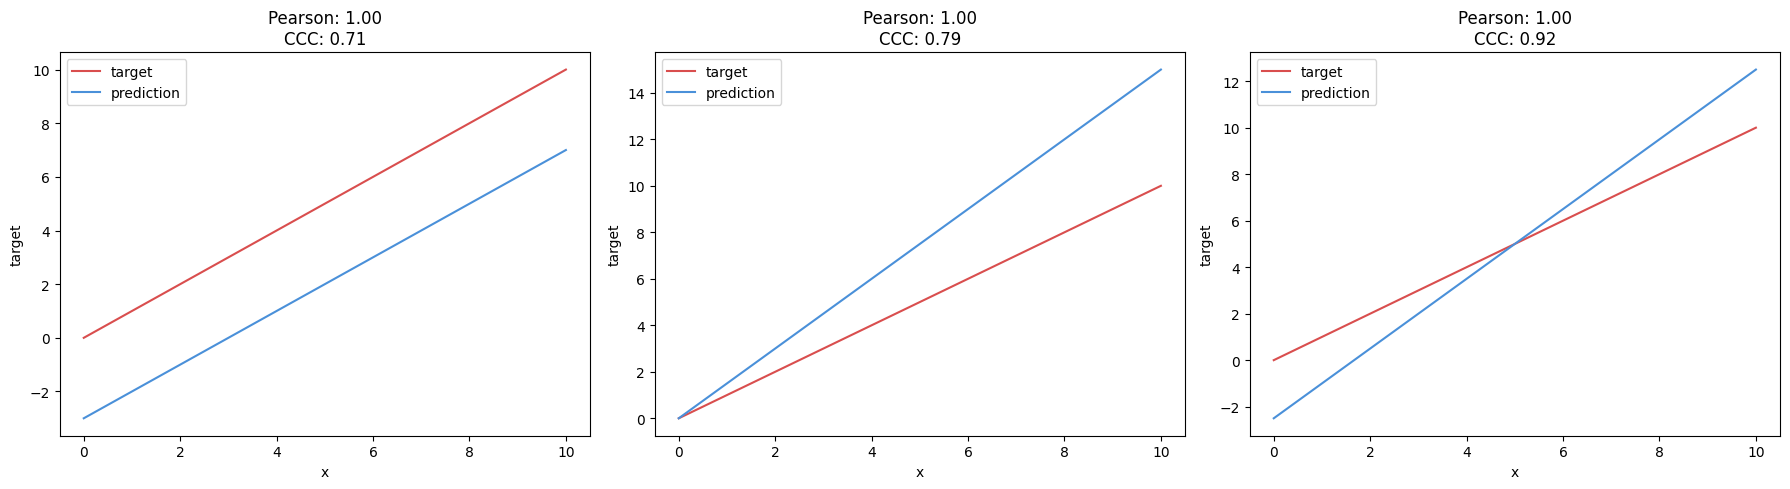

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils import testcolor, traincolor

def concordance_correlation_coefficient(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    cov_xy = np.cov(x, y)[0, 1]  # Covariance between x and y (sample covariance, ddof=1)
    var_x = np.var(x, ddof=1)     # Sample variance of x (ddof=1)
    var_y = np.var(y, ddof=1)     # Sample variance of y (ddof=1)
    
    # CCC formula
    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)
    return ccc


x           = np.arange(11)

df              = pd.DataFrame(x, columns=["x"])
df['target']    = df['x']
df['pred2']     = 1.5*df['x']
df['pred1']     = df['x'] - 3
df['pred3']     = 1.5*df['x'] - 2.5


# Prediction columns to loop over
pred_columns = ['pred1', 'pred2', 'pred3']

# Set up the subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

# Loop through prediction columns and plot
for i, pred_col in enumerate(pred_columns):
    # Pearson Correlation
    pearson_corr = df['target'].corr(df[pred_col])
    
    # Concordance Correlation Coefficient (CCC)
    ccc_value = concordance_correlation_coefficient(df['target'], df[pred_col])
    
    # Set the title for the subplot
    axes[i].set_title(f'Pearson: {pearson_corr:.2f}\nCCC: {ccc_value:.2f}')
    
    # Plot the lines for target and prediction
    sns.lineplot(df, x='x', y='target', label='target', color=testcolor, ax=axes[i])
    sns.lineplot(df, x='x', y=pred_col, label='prediction', color=traincolor, ax=axes[i])

# Adjust layout
plt.tight_layout()
plt.show()

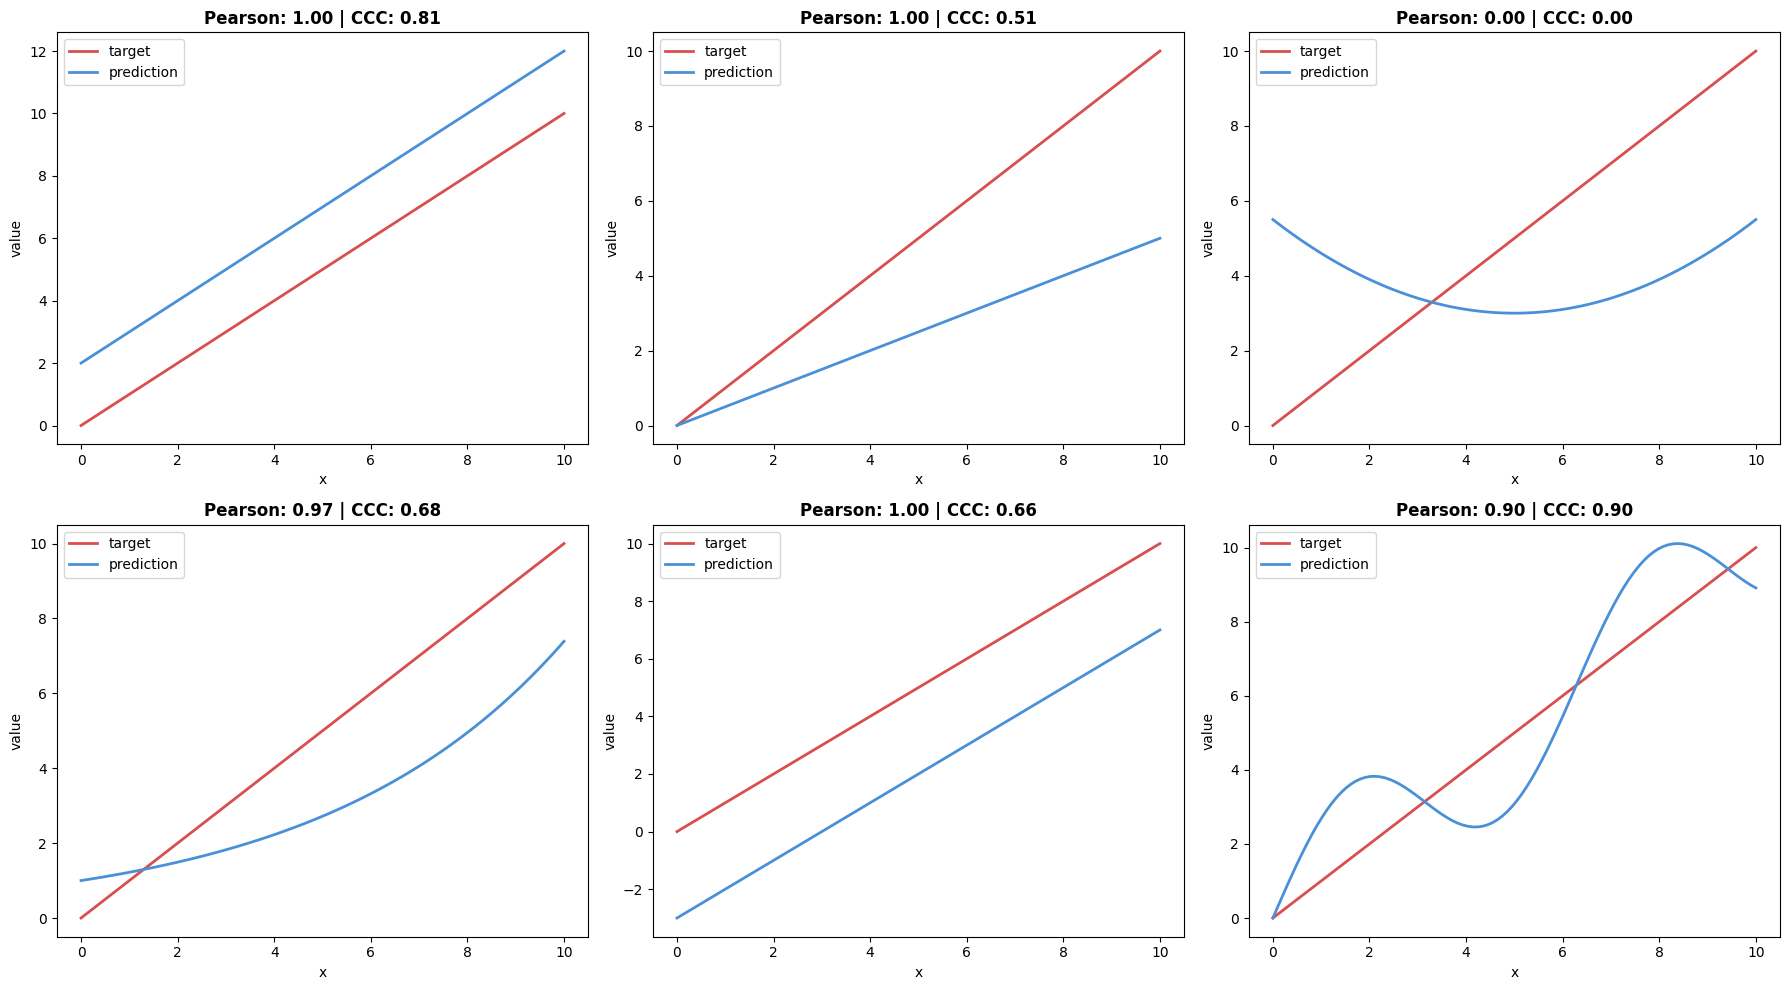

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils import testcolor, traincolor

def concordance_correlation_coefficient(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    cov_xy = np.cov(x, y)[0, 1]
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    
    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)
    return ccc


# Create various interesting examples
x = np.linspace(0, 10, 100)

df = pd.DataFrame(x, columns=["x"])
df['target'] = df['x']

# Example 1: Perfect linear relationship (shifted up)
df['pred1'] = df['x'] + 2

# Example 2: Perfect linear but different scale
df['pred2'] = 0.5 * df['x']

# Example 3: Nonlinear - quadratic relationship
df['pred3'] = 0.1 * (df['x'] - 5)**2 + 3

# Example 4: Nonlinear - exponential-like
df['pred4'] = np.exp(df['x'] / 5)

# Example 5: Systematic bias (constant offset)
df['pred5'] = df['x'] - 3

# Example 6: Nonlinear - sine wave around the line
df['pred6'] = df['x'] + 2 * np.sin(df['x'])

# Prediction columns to loop over
pred_columns = ['pred1', 'pred2', 'pred3', 'pred4', 'pred5', 'pred6']

# Set up the subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop through prediction columns and plot
for i, pred_col in enumerate(pred_columns):
    # Pearson Correlation
    pearson_corr = df['target'].corr(df[pred_col])
    
    # Concordance Correlation Coefficient (CCC)
    ccc_value = concordance_correlation_coefficient(df['target'], df[pred_col])
    
    # Set the title for the subplot
    axes[i].set_title(f'Pearson: {pearson_corr:.2f} | CCC: {ccc_value:.2f}', 
                      fontsize=12, fontweight='bold')
    
    # Plot the lines for target and prediction
    sns.lineplot(df, x='x', y='target', label='target', color=testcolor, ax=axes[i], linewidth=2)
    sns.lineplot(df, x='x', y=pred_col, label='prediction', color=traincolor, ax=axes[i], linewidth=2)

    axes[i].set_xlabel('x')
    axes[i].set_ylabel('value')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
*